<img src="https://www.epfl.ch/about/overview/wp-content/uploads/2020/07/logo-epfl-1024x576.png" width="140px" alt="EPFL_logo">

## Image Processing Laboratory Notebooks
---

This Jupyter Notebook is part of a series of computer laboratories that are designed
to teach image-processing programming; they are running on the EPFL's Noto server. They are the practical complement of the theoretical lectures of the EPFL's Master course 
[**MICRO-512 Image Processing II**](https://moodle.epfl.ch/course/view.php?id=522) taught by Prof. M. Unser and Prof. D. Van de Ville.

The project is funded by the Center for Digital Education and the School of Engineering. It is owned by the [Biomedical Imaging Group](http://bigwww.epfl.ch/). 
The distribution or reproduction of the notebook is strictly prohibited without the written consent of the authors.  &copy; EPFL 2026.

**Authors**: 
    [Pol del Aguila Pla](mailto:pol.delaguilapla@epfl.ch),
    [Kay Lächler](mailto:kay.lachler@epfl.ch),
    [Alejandro Noguerón Arámburu](mailto:alejandro.nogueronaramburu@epfl.ch),
    [Kamil Seghrouchni](mailto:kamil.seghrouchni@epfl.ch), and
    [Daniel Sage](mailto:daniel.sage@epfl.ch).
    
To ensure your work is graded correctly by our automated system, **do not create new cells or delete/rearrange/copy existing ones** when you submit. The current cells contain hidden metadata required for the auto-grader to identify your solutions. If you create temporary cells for testing during your work, remember to clean them up before submission.

# Lab 5.1: Geometric Transformation - Implementations
**Released**: Thursday, March 12, 2026

**Submission deadline**: Monday, March 23, 2026, before 23:59 on [Moodle](https://moodle.epfl.ch/course/view.php?id=463)

**Grade weight**: Lab 5 (26 points), 7.5 % of the overall grade

**Help Session**: Thursday, March 19, 2026

**Related lectures**: Chapter 7

### Student Name: 
### SCIPER: 

Double-click on this cell and fill your name and SCIPER number. Then, run the cell below to verify your identity in Noto and set the seed for random results.

In [ ]:
import getpass
# This line recovers your camipro number to mark the images with your ID
uid = int(getpass.getuser().split('-')[2]) if len(getpass.getuser().split('-')) > 2 else ord(getpass.getuser()[0])
print(f'SCIPER: {uid}')

# Geometric transformation - Implementations (14 points)

In this laboratory, we implement geometric transformations and interpolations of images, which we use for image processing applications.
We focus on geometric transformations of two-dimensional grayscale images; the same operations can be adapted to color images by treating each color channel as an independent grayscale image.

In this lab, we work on the image of the Eiffel Tower which the next cell depicts.

In [ ]:
%matplotlib widget
import imageio.v3 as imageio
from interactive_kit import imviewer as viewer
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage as nd

eiffel = imageio.imread('images/eiffel.png') / 255.

plt.close('all')
imgs_viewer = viewer(eiffel)

# Understanding geometry 

In this section we study the basics of geometric transformations, starting with transforming coordinate frames using a transformation matrix.
Then, we apply this to images by iterating through the pixels in the (to-be) transformed image and retrieving the value at their corresponding positions in the original image, requiring interpolation in almost all cases.
In this section, we use [*nearest neighbor*](https://en.wikipedia.org/wiki/Nearest-neighbor_interpolation) interpolation, and compare our results to SciPy.

## Rotation of the coordinate frame (1 point)

We parametrize a geometric transformation on a two-dimensional image by the angle of rotation, $\alpha \in [0, 2\pi)$, the scaling, $\rho>0$, and the center of the transformation $\mathbf{c}=(c_1, c_2)$.
Thus, the pixel at position $\mathbf{u}=(u_1, u_2)$ in the input image gets mapped to $\mathbf{v}=(v_1, v_2)$ in the output image according to

$$ (\mathbf{v} - \mathbf{c}) = \mathbf{A}(\mathbf{u} - \mathbf{c}) \Rightarrow \mathbf{v} = \mathbf{A}(\mathbf{u} - \mathbf{c}) + \mathbf{c},$$

where $\mathbf{A}$ applies a rotation and scaling of the coordinate frame. 

The convention in image processing is to **rotate the coordinate frame counterclockwise**, as opposed to rotating a point counterclockwise while keeping the same coordinate frame. In fact, the two operations are the inverse of each other (rotating the coordinate frame by $\alpha$ will look like rotating the point by $-\alpha$). Explore the image below and make sure you understand the concept before continuing.

![Forwarding](images/coord_frame_rotation.png)

### Multiple Choice Question

**For 1 point**, 

 * Which $2 \times 2$ matrix performs a rotation **of the coordinate frame** of angle $\alpha$ and a scaling by $\rho$? 
    1. $\rho \left[\begin{array}{ccc} \cos(\alpha) & \sin(\alpha)\\ -\sin(\alpha) & \cos(\alpha) \end{array}\right]$
    2. $\rho \left[\begin{array}{ccc} \cos(\alpha) & -\sin(\alpha)\\ \sin(\alpha) & \cos(\alpha) \end{array}\right]$
    3. $\frac{1}{\rho} \left[\begin{array}{ccc} \cos(\alpha) & \sin(\alpha)\\ -\cos(\alpha) & \sin(\alpha) \end{array}\right]$
    4. $\frac{1}{\rho}\left[\begin{array}{ccc} \cos(\alpha) & -\sin(\alpha)\\ \sin(\alpha) & \cos(\alpha) \end{array}\right]$

In [ ]:
# Modify the variable answer
answer = None
# YOUR CODE HERE

In [ ]:
# Sanity check
if answer not in [1, 2, 3, 4]:
    print('WARNING!\nValid answers are 1, 2, 3 and 4.')

## Implementing the geometric transformation (4 points)

To compute the transformation of an image, we iterate the pixels of the output image and retrieve the corresponding values from the input image, requiring solving the equation for $\mathbf{u}$:

$$\mathbf{u} = \mathbf{A}^{-1}(\mathbf{v}-\mathbf{c}) + \mathbf{c}\,.$$

**For 2 points**, implement `transformation_matrix` taking the arguments
* `angle`: the angle of *rotation of the coordinate frame* **in radian**,
* `scaling`: the scaling factor,

and returning
* a matrix containing the **inverse** of the matrix corresponding to the transformation.

In [ ]:
def transformation_matrix(angle, scale):
    mat = np.empty((2, 2))
    # YOUR CODE HERE
    return mat

In [ ]:
# We run a sanity check on `transformation_matrix`, applying it to several angles and scales.
# declare solutions for 0° and a scaling of one, and for 90° and a scaling of 2.
identity = np.array([[1, 0], [0, 1]])
r90s2 = np.array([[0, 0.5], [-0.5, 0]])

# the transformationn with 0° angle and unit scale should produce an identity matrix
if not np.allclose(transformation_matrix(0, 1), np.eye(2), rtol=1e-2):
    print('Warning: The output should be the identity matrix.')

# the transformation with -pi/2 angle and scaling of 2 should be an anti-diagonal matrix with values of +/-0.5
if not np.allclose(transformation_matrix(-np.pi / 2, 2), r90s2, rtol=1e-2):
    print('Warning: The output is not correct.')


For some transformations, for example, rotations by $\pi \mathbb{Z} / 2$, all pixel locations in the output image correspond to pixel locations in the input image.
However, this is not true in general and usually we need to interpolate the output value from input pixels surrounding the mapped location.
To start, we provide you with a nearest neighbor interpolator, but later we will implement more sophisticated interpolation methods.

In [ ]:
def nearest_interpolator(image, x):
    a, b = int(np.rint(x[0])), int(np.rint(x[1]))
    if not ((0 <= a < image.shape[0]) and (0 <= b < image.shape[1])):
        return 0.
    return image[a, b]

**For 2 points**, implement `transform`, transforming an image pixel-wise, with arguments
* `img`: the original image,
* `angle`: the rotation angle **in radians**,
* `scale`: the scaling factor,
* `c`: a pair of integers specifying the $x$- and $y$-coordinates of the center of rotation,
* `interpolator`: a function that performs the interpolation, with the signature as in the `nearest_interpolator`above

and returning
* `out`: the transformed image.

In particular, we need to compute the location in the original image, $\mathbf{u}$, from the inverse transformation matrix $\mathbf{A}^{-1}$, the center of the transformation $\mathbf{c}$, and the location in the output image $\mathbf{v}$, using the previously discussed formula. To facilitate implementation, we use a double-loop to iterate over each pixel explicitly, so that one only needs to find the formula for each pixel. Nevertheless, nested loops in Python are not favored for speed, and we will use library functions to perform the transform for more intensive computations later.

In [ ]:
def transform(img, angle, scale, c, interpolator):
    transformed = img.copy()
    Ainv = transformation_matrix(angle, scale)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            # YOUR CODE HERE
    return transformed

Let's perform a quick sanity check. We will apply your function on a small $5\times 5$ cross image, then visualize and compare transformations by $0^\circ$ and scaling factor $2$, and $40^\circ$ and scaling factor $1.01$, respectively, to see the effect of the nearest neighbor interpolation. Both transformations will be centered at the middle of the image, i.e., $\mathbf{c}=[2,2]^\mathrm{T}$. If your cell raises an error, explore the test in detail to see where it might come from.

In [ ]:
cross = np.array([
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [1, 1, 1, 1, 1],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
])

# Test for angle = 0, scale = 2 using NN interpolation
ref1 = np.array([
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
])
result1 = transform(cross, angle=0, scale=2, c=(2, 2), interpolator=nearest_interpolator)

# Test for angle = 40°, scale = 2 using NN interpolation
ref2 = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0],
])
result2 = transform(cross, angle=np.deg2rad(40), scale=1.01, c=(2, 2), interpolator=nearest_interpolator)

if not np.allclose(ref1, result1, rtol=1e-2):
    print('Your output is not correct.')
if not np.allclose(ref2, result2, rtol=1e-2):
    print('Your output is not correct.')


Although the sanity check was not applied to real images, we can already see all sorts of undesirable effects. Let's look at the result on a real image. 

## Visualizing transformations

We apply the transformation to the `eiffel` image, with the following $(\alpha, \rho)$ pairs using nearest neighbor interpolation: $(0^\circ, 1)$, $(0^\circ, 0.8)$, $(24^\circ, 2.5)$ and $(-20^\circ, 1)$.
Here, we can find errors that slipped through the previous test where the image was symmetric.

In [ ]:
angles = [0,   0,  24,  -20, -20]
scales = [1, 0.8, 2.5,    1,   1]
c1 = int(eiffel.shape[0] / 2)
c2 = int(eiffel.shape[1] / 2)
centers = np.array([[c1, c2], [c1, c2], [c1, c2], [c1, c2], [0, 0]])
images = np.empty((len(angles) + 1, *eiffel.shape))
images[0] = eiffel.copy()
titles = ['Original image']
for i, (angle, scale, center) in enumerate(zip(angles, scales, centers)):
    images[i + 1] = transform(eiffel, np.deg2rad(angle), scale, center, nearest_interpolator)
    titles.append(f"alpha={angle:.2f}, rho={scale:.2f}, c=({center[0]}, {center[1]})")

eiffel_viewer = viewer(list(images), title=titles, widgets=True)

## Geometric transformations in Python (1 point)

Geometric transformations are implemented in SciPy as `ndimage.affine_transform(img, M, order)`, with arguments
 *  `img`: the original image,
 *  `M`: a $2 \times 3$ matrix describing the transformation (see below),
 *  `order`: the order of the interpolation method to be used (`0`=nearest neighbor, `1`=linear, `3`=cubic),
 
and returns:
 *  `out`: the transformed image.


The matrix `M` described the affine transformation as follows:
The first two columns contain the transformation matrix mapping output coordinates to input coordinates, and the last column contains the shifts to be applied after the linear transformation.
This is advantageous because $\mathbf{u} = \mathbf{A}^{-1}(\mathbf{v} - \mathbf{c}) + \mathbf{c} = \mathbf{A}^{-1}\mathbf{v} + (\mathbf{I} - \mathbf{A}^{-1}) \mathbf{c}$, which is slightly more efficient as $(\mathbf{I} - \mathbf{A}^{-1})\mathbf{c}$ is precomputed; this is the third column of `M`.

In the cell below we can experiment with the different parameters, facilitating the understanding of the transformation matrix and `ndimage.affine_transform`.
To access the sliders, open the widget panel and click on *Extra widgets*, and choose $\alpha$ and $\rho$ using the slider.
Click on `Apply Transformation` to see the result.
If the sliders are hidden we can reveal them by scrolling to the right.

In [ ]:
angle_slider = widgets.FloatSlider(value=0, min=-30, max=30, step=0.5, description='$\\alpha$')
rho_slider = widgets.FloatSlider(value=1, min=0.1, max=4.09, step=0.1, description=r'$\\rho$')
c1_slider = widgets.IntSlider(value=eiffel.shape[0]//4, min=eiffel.shape[0]//8*1, max=eiffel.shape[0]//8*3, step=1, description='$c_1$')
c2_slider = widgets.IntSlider(value=eiffel.shape[1]//2, min=eiffel.shape[1]//4, max=eiffel.shape[1]//4*3, step=1, description='$c_2$')
button = widgets.Button(description='Apply transformation')


def transform_py(image):
    angle = angle_slider.value
    scale = rho_slider.value
    c = np.array([c1_slider.value, c2_slider.value])
    Ainv = transformation_matrix(np.deg2rad(angle), scale)
    M = np.hstack((
        Ainv,
        ((np.eye(2) - Ainv) @ c)[:, None],
    ))
    return nd.affine_transform(image, M, order=0)


# Visualize angle and scale effect during transformation
plt.close("all")
view = viewer([eiffel], title="Eiffel tower", new_widgets=[angle_slider, rho_slider, c1_slider, c2_slider, button], 
            callbacks=[transform_py], widgets=True)

Finally, we compare our `transform` against the SciPy implementation, setting  In setting `order=0` for nearest neighbor interpolation.

In [ ]:
ny, nx = eiffel.shape
c = np.array([ny//2, nx//2])
angle = 24
scale = 2.5
A = transformation_matrix(np.deg2rad(angle), scale)
M = np.hstack((
    A,
    ((np.eye(2) - A) @ c)[:, None],
))
transformed = nd.affine_transform(eiffel, M, order=0)
if np.allclose(transformed, images[3], rtol=1e-2):
    print('Congratulations! Your function gives the same result as some of the most accepted image processing libraries in the world.')
else:
    print('`transform` is incorrect. Inspect the images to look for differences.')
    plt.close('all')
    view = viewer([transformed, images[3]], title=["SciPy's output (Ground truth)", 'Your output'], widgets=True)

### Multiple Choice Question
Use the interactive viewer two cells above to answer the following question **for 1 point**. 

* What parameters should be used to align the Eiffel Tower vertically, with the main axis of the tower in the middle of the image while only keeping the upper part (only the region between the second and third platform) of the tower? See the image below:

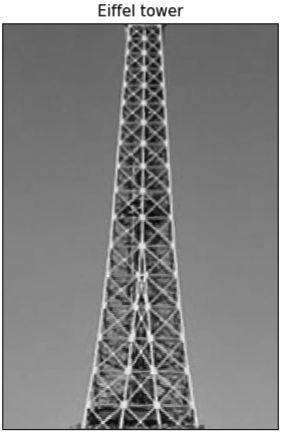

**Note: put the value for $\alpha$ in degrees!**

In [ ]:
# Modify the variable answer
alpha = None
rho = None
c_1 = None
c_2 = None
# YOUR CODE HERE

In [ ]:
if alpha < -90 or alpha > 90:
    print('Warning: Parameter is unreasonable.')

In [ ]:
if rho < 0 or rho > 4:
    print('Warning: Parameter is unreasonable.')

In [ ]:
if c_1 < 0 or c_1 > 690:
    print('Warning: Parameter is unreasonable.')

In [ ]:
if c_2 < 0 or c_2 > 440:
    print('Warning: Parameter is unreasonable.')

# B-spline interpolation

In this section, we replace nearest neighbor interpolation with linear interpolation.
As before, we compare our implementation to SciPy.

## Understanding the method (1 point) 

We compute the output image $g$, as a weighted sum of shifted two-dimensional B-spline basis functions $\boldsymbol{\beta}^n(\mathbf{x}) = \beta^n(x) \beta^n(y)$, i.e.,

$$
    g(\mathbf{x})=\sum_{\mathbf{k}\in\mathbb{Z}^2}c[\mathbf{k}]\boldsymbol{\beta}^n(\mathbf{x}-\mathbf{k})\mbox{, where } \mathbf{k}=(k_1,k_2)
$$

where $\mathbf{x} = (x,y)$ and $c$ are coefficients derived from the input image $s$ (see later).
More details about B-Splines can be found in Chapter 7.2 of the course notes.

In this section, we implement *linear interpolation* where $n = 1$, later we implement *cubic interpolation* where $n = 3$.
Since the basis functions $\beta^1$ are interpolant, the coefficients $c$ are identical to the input image, i.e., $c[k] = s[k]$ for all $k \in \mathbb{Z}^2$.
In contrast, the basis functions $\beta^3$ are not interpolant, and we compute $c$ from $s$ using a pre-filter.

**For 1 point**, answer the following MCQ:
 * What are $\beta^1(0)$ and $\beta^3(0)$ and what is the size of their support (the support of a function f is the set $\lbrace x\in\mathbb{R}: f(x)>0 \rbrace$) of $\beta^1$ and $\beta^3$?

1. $\beta^1(0) = \frac{2}{3}$ and its support is of size $4$, and $\beta^3(0) = 1$ and its support is of size $2$,
2. $\beta^1(0) = 1$ and its support is of size $2$, and $\beta^3(0) = 1$ and its support is of size $2$,
3. $\beta^1(0) = \frac{2}{3}$ and its support is of size $4$, and $\beta^3(0) = \frac{6}{8}$ and its support is of size $3$,
4. $\beta^1(0) = 1$ and its support is of size $2$, and $\beta^3(0) = \frac{2}{3}$ and its support is of size $4$.

In [ ]:
# Modify the variable answer
answer = None
# YOUR CODE HERE

In [ ]:
# Sanity check
if answer not in [1, 2, 3, 4]:
    print('WARNING!\nChoose one of 1, 2, 3 or 4.')

## Linear interpolation (3 points)

The image below illustrates linear interpolation with a $4$ pixel image where we compute the value of the image at the location $(dx,dy)$.
This suffices to describe the general case of linear interpolation since only the $4$ neighboring pixels affect the value at any location, and $(dx,dy)$ can be seen as the distances as the fractional part of any location $(x, y)$.

To compute the image value at $(x, y)$ using linear interpolation, we extract the $2\times 2$ neighborhood around $(x, y)$, referring to the pixels as $s[k, l]$, with $k, l = 0$ corresponding to the integers immediately below $(x,y)$, and $k,l=1$ corresponding to the integers immediately above $(x,y)$. Then, the $4$ weights to apply to each of them are extracted from the values of $\beta^1(\mathbf{x}-(0,0))$, $\beta^1(\mathbf{x}-(0,1))$, $\beta^1(\mathbf{x}-(1,0))$, and $\beta^1(\mathbf{x}-(1,1))$ at the location $\mathbf{x}=(dx,dy)$.  Finally, because in linear interpolation $c[k]=s[k]$, the interpolation is the linear combination of the four pixels with these weights.

![Bilinear interpolation](images/bilinear_interpolation_showcase.png)

From $dx$ and $dy$, the weights given by $\beta^1(\mathbf{x})$ are, for $k,l\in\lbrace 0,1\rbrace$,

$$
\beta^1[k, l]=
    \begin{bmatrix}
        (1-dx)(1-dy) & dx(1-dy) \\
        (1-dx)dy & dxdy
    \end{bmatrix}
$$

and the interpolated value becomes

$$
    v = \sum_{k=0}^{1}\sum_{l=0}^{1}\beta^1[k,l]s[k,l]\,,
$$

with the convention for $s[k,l]$ explained above.

**For 1 point**, implement `linear_spline`, returning a $2\times 2$ array representing the weight $\beta^1$ for $(dx, dy) \in [0,1]^2$.

In [ ]:
def linear_spline(dx, dy):
    spline = np.ones((2, 2))
    # YOUR CODE HERE
    return spline

Before proceeding, we will perform a sanity check as usual. Verify that the output values also make sense to you.

In [ ]:
# Check some simple interpolation cases
in_values = [[0, 0], [1, 0], [0.5, 0.5], [0.75, 0.25]]
references = np.array([[[1, 0], [0, 0]], [[0, 1], [0, 0]], [[0.25, 0.25], [0.25, 0.25]], [[0.188, 0.563], [0.063, 0.188]]])
check_error = False
for value, reference in zip(in_values, references):
    print(f'Linear spline weights for (dx, dy) = ({value[0]}, {value[1]}):')
    spline = linear_spline(value[0], value[1])
    print(spline)
    if not np.allclose(spline, reference, rtol=1e-2):
        print('WARNING!')
        print(f'The result for (dx, dy) = ({value[0]}, {value[1]}) does not match the reference:')
        print(f'Expected:\n {reference}\nResult: {spline}\n')
        check_error = True
    else:
        print('This is correct.\n---------------\n')

if not check_error:
    print('Nice, the B-splines seem to be correct.')


**For 2 points**, implement `linear_interpolator`, taking as arguments
 * `img`: the image to interpolate the value from,
 * `x`: a pair $(x_1, x_2)$ describing the location,
and returning the linearly interpolated value at the given location.


💡 *Hints:*
* *Use `linear_spline` from above to obtain the right weights for each of the surrounding pixels.*
* *Be careful of the correspondence between the coordinates $dx, dy$ and the axes of input location.*
* *Be careful of what happens outside of the image.*
* *NumPy has an implementation of $\lfloor \, \cdot \, \rfloor$.*

In [ ]:
def linear_interpolator(img, x):
    res = 0

    # YOUR CODE HERE
    
    return res

Now run the next cell to perform a sanity check on this function as well.

In [ ]:
test_linear = np.array([
    [1, 2, 3, 4, 5],
    [6, 7, 8, 9, 10],
    [11, 12, 13, 14, 15]
], dtype=np.float32)
locs = [[1, 3], [1.5, 1.5]]
vals = [9, 10]
check_error = False
print('Input image for sanity check:', test_linear)
for i, loc in enumerate(locs):
    test_val = linear_interpolator(test_linear, loc)
    print(f'Your interpolated value at location {loc} is {test_val}.')
    if not test_val == vals[i]:
        print('WARNING!')
        print('The linear_interpolator is not yet correct. The expected value at {loc} is {vals[i]}.\n---------------\n')
        check_error = True
    else:
        print('This is correct.\n---------------\n')

if not check_error:
    print('Nice, the linear_interpolator function passed the sanity check!')


Now we compare the output of our `transform` function to the output of `scipy.ndimage.affine_tranform`, using linear interpolation for both.
Run the two cells to see if your transform function works correctly with linear interpolation.

In [ ]:
scale = 1.2
center = (282, 355)
angle = -72

ours = transform(eiffel, np.deg2rad(angle), scale, center, interpolator=linear_interpolator)

A = transformation_matrix(np.deg2rad(angle), scale)
M = np.hstack((A, ((np.eye(2) - A) @ center)[:, None]))
# order=1 corresponds to linear interpolation
transformed = nd.affine_transform(eiffel, M, order=1, mode='grid-constant')

# Check that the images are identical
if np.allclose(transformed, ours, rtol=1e-2):
    print("Good job! The transformation with linear interpolation gives the same result as scipy's.")
else:
    plt.close('all')
    print('WARNING!\nThe transformation with linear interpolation is not correct.\nSee the images below and try to find the source of the error.')
    title_list = ['Python transformation', 'Your transformation']
    view = viewer([transformed, ours], title=title_list, widgets=True, subplots=(1,2), compare=True)

# Cubic interpolation 

In the previous section, we saw that linear interpolation improves over nearest neighbor interpolation.
Now, we implement cubic interpolation using cubic splines.
In this case, we need to implement a prefilter to compute coefficients $c$ derived from the image first.

## Prefilter (2 points)

The computation of the values $c[\mathbf{k}]$ from the image $s[\mathbf{k}]$ is separable.
A fast implementation of the one-dimensional prefilter to obtain the coefficients $c[k]$ in the cubic interpolator is obtained by a cascade of recursive filters schematized below, where $c_{0}=6$ and ${a}=\sqrt{3}-2$:

![Drawing](images/diagram.jpg)

Before we implement this filter in `symmetric_exponential_filter_cascade` below, we define `prefilter` which calls it on the rows and the columns of an image to compute the coefficients $c[\mathbf{k}]$ of an image $s[\mathbf{k}]$.
We also provide the functions.
There, we also define the functions `initial_causal_coefficient` and `initial_anticausal_coefficient` that help you in your implementation and take as input parameters
* `signal`: a one-dimensional signal, and
* `a`: the value of $a$ in the diagram above,

and returns

* the initial value for the causal and anticausal filters, respectively.

In [ ]:
def initial_causal_coefficient(signal, a):
    k0 = min(12, len(signal))
    polek = a
    v = signal[0]
    for k in range(1, k0):
        v += polek * signal[k]
        polek *= a
    return v


def initial_anticausal_coefficient(signal, a):
    return (a / (a * a - 1.0)) * (signal[-1] + a * signal[-2])


def prefilter(image):
    convolved = np.empty_like(image)
    for i in range(image.shape[0]):
        convolved[i] = symmetric_exponential_filter(image[i])

    for j in range(image.shape[1]):
        convolved[:, j] = symmetric_exponential_filter(convolved[:, j])
    return convolved

**For 3 points**, implement `symmetric_exponential_filter` that recursively filters a one-dimensional signal.
This function has the input parameter:

* `signal`: a one-dimensional array representing the input signal

and returns:

* a one-dimensional array that contains the coefficients $c[k]$ corresponding to the input signal. 

    
💡 Hints: 
- $\operatorname{H}(z) = \sum_{m=0}^{M-1}b_m z^{-m} \left/ \sum_{n=0}^{N-1}a_n z^{-n}\right.$ is equivalent to $\sum_{n=0}^{N-1}a_n y[k-n] = \sum_{m=0}^{M-1}b_m x[k-m]$.
- `initial_causal_coefficient` gives $y[0]$ for the causal filter and `initial_anticausal_coefficient` gives $y[w-1]$ for the anticausal filter.

In [ ]:
def symmetric_exponential_filter(signal):
    output = signal.copy()
    c0 = 6.
    a = np.sqrt(3) - 2
    
    # YOUR CODE HERE
    return output

As a sanity check, we will apply your function to an impulse sequence of length 11. Run the next cell to do so.

In [ ]:
impulse = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
], dtype=np.float32)
reference = np.array([-0.00952004, 0.0190401, -0.06664035, 0.24752128, -0.92344475, 3.4462576, -0.9234448, 0.24752128, -0.06664035, 0.0190401, -0.00952005])

# Compare central row
ours = prefilter(impulse)[impulse.shape[0] // 2]
print(ours)

if not np.allclose(ours, reference, rtol=1e-2):
    print("The recursive exponential filter implementation is incorrect.")
else:
    print('The implementation passed the sanity check.')

## Cubic interpolation (2 points) 

With the correct coefficients, we can complete `cubic_interpolator` below. 
We provide `cubic_spline` returning a $4\times4$ array containing the two-dimensional cubic B-spline $\beta^3$ values.
This is the analog to `linear_spline` for cubic interpolation.

In [ ]:
def cubic_spline(dx, dy):
    output = np.zeros((4, 4))
    
    def v(t):
        out = np.empty((4, ))
        out[0] = (1.0 - t)**3 / 6.0
        out[1] = (2.0 / 3.0) - 0.5 * t**2 * (2 - t)
        out[3] = t**3 / 6.0
        out[2] = 1.0 - out[3] - out[1] - out[0]
        return out

    vx = v(dx)
    vy = v(dy)
    return vx[None, :] * vy[:, None]

**For 2 points** implement `cubic_interpolator` taking the arguments
 * `img`: the image to interpolate the value from,
 * `x`: a pair $(x_1, x_2)$ describing the location,

and returning the cubicly interpolated value at the given location.

The implementation is similar to the linear case.

💡 *Hints:*
* *Be careful of the correspondence between the coordinates $dx, dy$ and the axes of input location.*
* *Be careful of what happens outside of the image.*

In [ ]:
def cubic_interpolator(img, x):
    res = 0

    # YOUR CODE HERE
    return res

Now run the next cell to perform a quick sanity check as always.

In [ ]:
image = np.array([
    [1, 2, 3, 4, 5],
    [6, 7, 8, 9, 10],
    [11, 12, 13, 14, 15]
], dtype=np.float32)

for location, ref in zip([(1, 3), (1.5, 1.5)], [9.0, 9.6354]):
    ours = cubic_interpolator(image, location)
    if np.abs(ours - ref) > 0.001:
        print(f'Warning: `cubic_interpolator` is incorrect: The expected value at location {location} is {ref:.4f}, but got {ours:.4f}.')


In the next cells we again compare our implementation to scipy's.
After running the next two cells, you will see either see a winning message, or you transformed image display with some regions in red.
These regions show the differences between your implementation and the Python implementation. Use this info to debug your cubic interpolation.

In [ ]:
angle = 45 # in degrees
scale = 2
center = np.array([150, 250])
ours = transform(prefilter(eiffel), np.deg2rad(45), scale, center, cubic_interpolator)

In [ ]:
A = transformation_matrix(np.deg2rad(angle), scale)
M = np.hstack((A, ((np.eye(2) - A) @ center)[:, None]))

reference = nd.affine_transform(prefilter(eiffel), M, order=3, mode='grid-constant', prefilter=False)

if np.allclose(ours, reference, rtol=1e-2):
    print('The transformation with cubic interpolation is correct.')
else:
    print('Warning: The transformation with cubic interpolation is not yet correct. Check the images to try to find the source of the error.')
    plt.close('all')
    viewer([reference, ours], title=['SciPy (Ground truth)', 'Ours'], widgets=True, compare=True)

**It is worth mentioning that many authors in image processing leave out the essential prefiltering step ... This has a catastrophic effect on performance and perpetuates the incorrect belief that high-order B-spline interpolation results in increased image blurring.**
*M. Unser, "Splines: a perfect fit for signal and image processing," in IEEE Signal Processing Magazine, vol. 16, no. 6, pp. 22-38, Nov. 1999, DOI: [10.1109/79.799930](https://ieeexplore.ieee.org/abstract/document/799930)*
 
As a quick demonstration, run the next cell where we will plot a transformation with and without the prefilter. Zoom into the high frequency regions to see the blurring caused by lack of knowledge!

In [ ]:
A = transformation_matrix(np.deg2rad(angle), scale)
M = np.hstack((A, ((np.eye(2) - A) @ center)[:, None]))
filtered = nd.affine_transform(eiffel, M, order=3)
unfiltered = nd.affine_transform(eiffel, M, order=3, prefilter=False)

# Visualize
plt.close('all')
view = viewer([filtered, unfiltered], title=['Prefiltered (Ground truth)', 'Not prefiltered (Wrong)'], 
              widgets=True, subplots=(1,2))

## Visual comparison

Finally, we look at the difference between the interpolators by running the same transformation and visualizing the results.
In the second part of this lab, we will compare the three interpolation methods numerically to see what we gain from a more complex interpolation.
Feel free to change the parameters of the transformation to see different results.

In [ ]:
angle = 30 # in degrees
scaling = 2
center = (360, 245)

nearest, linear, cubic = [
    transform(eiffel, np.deg2rad(angle), scaling, center, interpolator=interpolator)
    for interpolator, im in zip([nearest_interpolator, linear_interpolator, cubic_interpolator], [eiffel, eiffel, eiffel])
]

In [ ]:
plt.close('all')
view = viewer([nearest, linear, cubic], 
              title=['Nearest neighbor', 'Linear', 'Cubic'], subplots=(2,2), widgets=True)

🎉 Congratulations on finishing the first part of the geometric transformation lab!

Make sure to save your notebook (you might want to keep a copy on your personal computer) and upload it to Moodle, **in a zip file with the other notebook of this lab.**

* Keep the name of the notebook as: *1_gt_implementations.ipynb*,
* Name the zip file: *geometric_transformation_lab.zip*.